<a href="https://colab.research.google.com/github/JuanPabloArriagada/BIY7121_GRUPO_1/blob/main/BIY7121_Entrega_2_G1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Evaluación 2

---

**Autores:**


1. Juan-Pablo Arriagada
2. Benjamin Monsalve

---

**Correos Electrónicos:**
1. ju.arriagada@duocuc.cl
2. ben.monsalve@duocuc.cl

**fecha de Creación:** 27 de Abril

**Versión:** 1.0

---

##Descripción

**Este notebook fue desarrollado para realizar la evaluación 2**

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)






In [ ]:
!wget = https://raw.githubusercontent.com/BenjvminIgn/Mineria-de-datos/refs/heads/main/data_clima_2025_final.csv

--2026-05-18 03:07:52--  http://=/
Resolving = (=)... failed: Name or service not known.
wget: unable to resolve host address ‘=’
--2026-05-18 03:07:52--  https://raw.githubusercontent.com/BenjvminIgn/Mineria-de-datos/refs/heads/main/data_clima_2025_final.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4527300 (4.3M) [text/plain]
Saving to: ‘data_clima_2025_final.csv.7’

data_clima_2025_fin 100%[===================>]   4.32M  19.8MB/s    in 0.2s    

2026-05-18 03:07:53 (19.8 MB/s) - ‘data_clima_2025_final.csv.7’ saved [4527300/4527300]

FINISHED --2026-05-18 03:07:53--
Total wall clock time: 0.6s
Downloaded: 1 files, 4.3M in 0.2s (19.8 MB/s)


#Librerias


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

In [ ]:
data = pd.read_csv('data_clima_2025_final.csv')
data.head()

,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


## **Contexto de la empresa e historia**

La empresa LengaMar Transporte y Turismo SpA es una compañía ubicada en la Región del Biobío dedicada al transporte marítimo turístico y al traslado de pasajeros en zonas costeras. Inicialmente, la empresa operaba principalmente en el sector de Caleta Lenga, ofreciendo servicios de recorridos turísticos y transporte hacia distintos puntos del litoral.

Debido al crecimiento del turismo en el sur de Chile y a la variabilidad de las condiciones climáticas entre distintas localidades, la empresa está evaluando expandir sus operaciones hacia otras ciudades del centro-sur del país, como Valdivia, Puerto Montt y Temuco, considerando conexiones turísticas con lagos y zonas costeras cercanas.

Para tomar decisiones informadas sobre esta expansión, la empresa busca analizar datos meteorológicos históricos con el fin de identificar patrones climáticos que puedan afectar la operación del negocio, tales como variaciones de temperatura, percepción térmica y condiciones que puedan influir en la demanda turística o en la cancelación de viajes.



## **Origen de los datos**

Los datos utilizados para el análisis provienen de registros meteorológicos históricos obtenidos a través de la plataforma Open-Meteo, la cual entrega información climática recopilada desde estaciones meteorológicas y modelos meteorológicos globales.

El conjunto de datos incluye observaciones diarias correspondientes al año 2025 e incorpora variables como:

* Temperatura
* Precipitación
* Velocidad del viento
* Humedad
* Presión atmosférica
* Ocurrencia de lluvias

Estos datos permiten analizar cómo las condiciones climáticas afectan la operación diaria de las lanchas, considerando que factores como vientos fuertes o lluvias pueden limitar o incluso suspender los servicios marítimos.

## **¿Por qué es útil analizar estos datos?**

Analizar los datos climáticos permite a la empresa mejorar la toma de decisiones operativas y estratégicas.

En primer lugar, el análisis de datos permite identificar patrones climáticos que afectan la operación de las lanchas, como temporadas con mayor presencia de viento o lluvias, lo que ayuda a planificar de mejor manera los horarios de salida y la disponibilidad del servicio.

Además, el análisis permite anticipar condiciones adversas que podrían afectar la seguridad de los pasajeros o la continuidad del servicio. Esto facilita la planificación de recursos, la programación del mantenimiento de las embarcaciones y la comunicación oportuna con los clientes.

Finalmente, mediante técnicas de análisis de datos y minería de datos, la empresa puede desarrollar modelos que permitan predecir días con condiciones favorables o desfavorables para la navegación, optimizando así su operación, reduciendo riesgos y mejorando la experiencia de los usuarios.

#Fase 2 - Entiendimiento de los datos

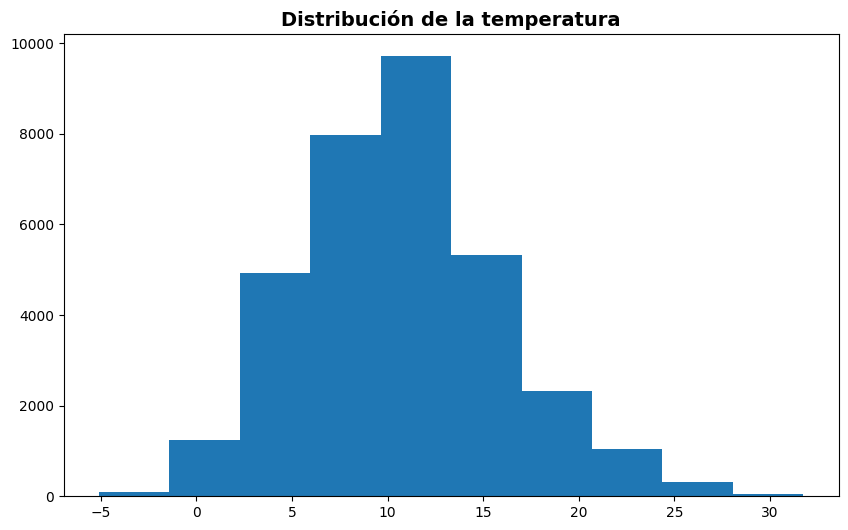

In [ ]:
data.temperature_2m.hist(bins=10, figsize=(10,6), grid=False)
plt.title("Distribución de la temperatura", fontsize=14, fontweight="bold")
plt.show()

**Interpretación del grafico:**
- El grafico de cierta manera se ve normal, tiene una forma medianamente acampanada, donde se puede ver que la mayoria de los datos están en el centro

##Valores duplicados

In [ ]:
#obtenemos la cantidad total de los valores duplicados
data.duplicated().sum()

np.int64(0)

se observa que no hay valores duplicados

**En caso de que existan**
- se debe realizar una análisis si es un error de carga de datos pero esto depende de si hay un ID que los diferencie ya que si hay un identificador que sea igual a otro registro, eso sería un error de datos y por ende se deberia eliminar para evitar el overfiting, también está la casualidad de que justo tenga los mismos valores ambos registros pero tengan distinto ID ahí se debería conservar el registro "duplicado"


##Valores nulos

In [ ]:
data.isnull().sum().rename("Cantidad de nulos")

,Cantidad de nulos
date,0
temperature_2m,0
relative_humidity_2m,0
apparent_temperature,0
precipitation,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
rain,0
is_day,0


Se observa que no hay valores nulos

**En caso de que existan**

-En caso de que lo hubiesen, la mejor manera de tratar valores nulos es usando el imputer, pero esto depende del proyecto, en algunos es más viable usar la media, en otros la mediana o la moda

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

**Se observa que no hay valores nulos.**

Podemos ver que hay un total de 33024 registros, 21 columnas en nuestro set de datos como así también podemos ver los tipos de datos de cada columna

- 1 columna con tipo datetime
- 16 float64
- 2 columnas tipo int32
- 1 columna tipo int64
- 1 columna tipo object

##Valores atipicos

In [ ]:
#Entendemos los valores minimos y maximos de cada columna
data.describe()

,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,latitud,longitud,is_rainy_hour
count,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000,33024.000000
mean,10.644075,79.042842,8.337603,0.138981,62.114977,11.930189,205.227225,0.136601,0.495882,1221.216663,-42.134914,-72.448638,0.184714
std,5.213359,16.228987,6.350746,0.582210,41.871036,8.474665,101.410042,0.577866,0.499991,1650.360797,6.456137,0.920869,0.388071
min,-5.100000,15.230701,-8.741941,0.000000,0.000000,0.000000,0.367278,0.000000,0.000000,0.000000,-53.162569,-73.245986,0.000000
25%,7.050000,68.349886,3.876656,0.000000,13.000000,5.649248,139.531913,0.000000,0.000000,0.000000,-43.151237,-73.099151,0.000000
50%,10.400000,82.217838,8.232820,0.000000,88.000000,9.940824,229.398790,0.000000,0.000000,0.000000,-39.275008,-72.820372,0.000000
75%,13.700000,92.891105,12.350445,0.000000,100.000000,15.882896,284.036250,0.000000,1.000000,3600.000000,-38.258686,-72.169859,0.000000
max,31.750000,100.000000,32.108310,13.200000,100.000000,65.250920,360.000000,13.200000,1.000000,3600.000000,-36.827070,-70.907822,1.000000


In [ ]:
#Contar valores atipicos
print("Análisis de columnas con valores atípicos (usando el método IQR): \n")

def contarAtipicos(data):
  #obtenenmos todas las columnas que sean del tipo numerica
  col_numericas = data.select_dtypes(include=['number']).columns
  for col in col_numericas:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    cantidad_atipicos = data[(data[col] < limite_inferior) | (data[col] > limite_superior)].shape[0]
    print(f"La columna {col} tiene {cantidad_atipicos} valores atípicos.")

#Muestra la cantidad de atipicos
contarAtipicos(data)


Análisis de columnas con valores atípicos (usando el método IQR): 

La columna temperature_2m tiene 476 valores atípicos.
La columna relative_humidity_2m tiene 130 valores atípicos.
La columna apparent_temperature tiene 282 valores atípicos.
La columna precipitation tiene 6152 valores atípicos.
La columna cloud_cover tiene 0 valores atípicos.
La columna wind_speed_10m tiene 1241 valores atípicos.
La columna wind_direction_10m tiene 0 valores atípicos.
La columna rain tiene 6100 valores atípicos.
La columna is_day tiene 0 valores atípicos.
La columna sunshine_duration tiene 0 valores atípicos.
La columna latitud tiene 8256 valores atípicos.
La columna longitud tiene 0 valores atípicos.
La columna is_rainy_hour tiene 6100 valores atípicos.


Se obtuvieron valores atipicos en distintas columnas de nuestra data

**Como tratarlas?**

-La manera de tratar los valores atipicos sería usando el pipeline winsorizer, ya que acerca en cierta medida los valores alejados de la media

##Valores inconsistentes

In [ ]:
# Lista donde se almacenan todas las condiciones inválidas
condiciones_invalidas = []

# -------------------------
# Reglas generales
# -------------------------

# Humedad relativa entre 0 y 100
condiciones_invalidas.append((data["relative_humidity_2m"] < 0) | (data["relative_humidity_2m"] > 100))

# Nubosidad entre 0 y 100
condiciones_invalidas.append((data["cloud_cover"] < 0) | (data["cloud_cover"] > 100))

# Dirección del viento entre 0 y 360
condiciones_invalidas.append((data["wind_direction_10m"] < 0) | (data["wind_direction_10m"] > 360))

# Variables que NO pueden ser negativas
variables_no_negativas = [
    "precipitation",
    "rain",
    "wind_speed_10m",
    "sunshine_duration"
    ]

for col in variables_no_negativas:
    condiciones_invalidas.append(data[col] < 0)

# Variables binarias
variables_binarias = [
    "is_day",
    "is_rainy_hour"
]

for col in variables_binarias:
    condiciones_invalidas.append(~data[col].isin([0, 1]))

# Coordenadas válidas
condiciones_invalidas.append(
    (data["latitud"] < -90) |
    (data["latitud"] > 90)
)

condiciones_invalidas.append(
    (data["longitud"] < -180) |
    (data["longitud"] > 180)
)


# Si es de noche, no debería existir duración de sol
condiciones_invalidas.append(
    (data["is_day"] == 0) &
    (data["sunshine_duration"] > 0)
)

# Si no llueve, la lluvia debería ser 0
condiciones_invalidas.append(
    (data["precipitation"] == 0) &
    (data["rain"] > 0)
)

# -------------------------
# Unión de condiciones
# -------------------------

# Combina todas las condiciones inválidas
mascara_inconsistencias = condiciones_invalidas[0]

for condicion in condiciones_invalidas[1:]:
    mascara_inconsistencias |= condicion

# DataFrame final de inconsistencias
inconsistentes = data[mascara_inconsistencias]

# -------------------------
# Resultados
# -------------------------

print(f"Total de registros inconsistentes detectados: {len(inconsistentes)}")

display(inconsistentes)

Total de registros inconsistentes detectados: 356


,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
861,2025-02-06 00:00:00+00:00,16.800,85.754070,15.777412,0.0,6.0,16.932442,226.29208,0.0,0.0,1959.754300,"Concepción, Chile",-36.827070,-73.050206,0
885,2025-02-07 00:00:00+00:00,18.500,74.103165,17.329601,0.0,0.0,16.452040,216.99536,0.0,0.0,1904.175700,"Concepción, Chile",-36.827070,-73.050206,0
909,2025-02-08 00:00:00+00:00,18.400,63.714237,15.985689,0.0,0.0,19.513195,217.50421,0.0,0.0,1847.275800,"Concepción, Chile",-36.827070,-73.050206,0
933,2025-02-09 00:00:00+00:00,20.100,65.783430,18.525667,0.0,90.0,18.491003,211.05934,0.0,0.0,1789.140000,"Concepción, Chile",-36.827070,-73.050206,0
957,2025-02-10 00:00:00+00:00,20.650,55.401280,17.424202,0.0,48.0,25.071098,212.09256,0.0,0.0,1510.730100,"Concepción, Chile",-36.827070,-73.050206,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32686,2025-11-27 01:00:00+00:00,6.212,67.856330,1.503465,0.0,1.0,18.491003,238.94066,0.0,0.0,6.417383,"Punta Arenas, Chile",-53.162569,-70.907822,0
32734,2025-11-29 01:00:00+00:00,7.362,63.387886,2.744784,0.0,10.0,18.032370,243.94656,0.0,0.0,9.745090,"Punta Arenas, Chile",-53.162569,-70.907822,0
32854,2025-12-04 01:00:00+00:00,6.912,69.980200,1.088742,0.0,35.0,27.396093,306.71940,0.0,0.0,195.825520,"Punta Arenas, Chile",-53.162569,-70.907822,0
32878,2025-12-05 01:00:00+00:00,6.912,69.730600,0.785679,0.0,49.0,29.414997,279.86575,0.0,0.0,207.493990,"Punta Arenas, Chile",-53.162569,-70.907822,0


Se observa que hay 356 registros con valores inconsistentes

**¿Como tratarlos?**

Se detectaron registros aparentemente inconsistentes donde:
- is_day == 0 (noche)
- sunshine_duration > 0
Sin embargo, estos registros no corresponden a errores reales de medición.

La API Open-Meteo entrega los timestamps en formato UTC (+00:00), mientras que el análisis del dataset se realiza considerando horario local de Chile
(America/Santiago). Esto genera un desfase horario entre la variable temporal y la interpretación de día/noche. Por esta razón, algunos registros aparecen como "noche" en UTC, pero aún corresponden a horas con presencia de sol en horario local.

Debido a que los valores meteorológicos son físicamente coherentes, el patrón es consistente y sistemático, y no corresponde a corrupción de datos, estos registros no serán eliminados ni modificados manualmente.

In [ ]:
#obtenemos las localidades para ver si hay inconsistencias
data.Localidad.unique()

array(['Concepción, Chile', 'Temuco, Chile', 'Valdivia, Chile',
       'Punta Arenas, Chile'], dtype=object)

No se observar inconsistencias en los nombres de las localidades

#Fase 3 - Preparación de datos

## Tratamientos

### Duplicados

In [ ]:
# DUPLICADOS
def tratar_duplicados(X : pd.DataFrame, drop = True):
  return X.drop_duplicates() if drop else X

Elimina filas duplicadas exactas para evitar redundancia y posibles sesgos en el análisis o entrenamiento del modelo.

### Atipicos

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

Winsorizer es un transformador personalizado que limita los valores extremos (outliers) de las variables numéricas utilizando percentiles.
Su objetivo es reducir el impacto de valores atípicos sin eliminar registros del dataset.

El proceso consiste en:

calcular un límite inferior y superior según los percentiles definidos,
reemplazar los valores menores al límite inferior por dicho límite,
reemplazar los valores mayores al límite superior por el límite máximo permitido.

Esto permite mantener la distribución general de los datos mientras se reduce la influencia de observaciones extremas en el entrenamiento de modelos de Machine Learning.

### Nulos

In [ ]:
SimpleImputer(strategy="mean")

SimpleImputer()

Se utiliza la estrategia "mean" porque las variables numéricas del dataset representan mediciones continuas del clima, como temperatura, humedad, velocidad del viento o precipitación.

El promedio permite estimar valores faltantes utilizando el comportamiento general de la variable, manteniendo la escala y distribución de los datos sin introducir valores extremos artificiales. Además, es una técnica simple y eficiente para datasets meteorológicos con baja cantidad de datos faltantes.

### CorrelationFilter

In [ ]:
# ELIMINAR VARIABLE CORRELACION Y ASEGURAR NUMERICOS
class CorrelationFilter(BaseEstimator, TransformerMixin):
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None
    self.numeric_cols_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)
    # Identificamos solo columnas numéricas
    X_numeric = X_df.select_dtypes(include=[np.number])
    self.numeric_cols_ = X_numeric.columns.tolist()

    if X_numeric.empty:
        self.columns_to_drop_ = []
        return self

    corr_matrix = X_numeric.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    # Primero, nos quedamos solo con las que eran numéricas en el fit
    X_filtered = X_df[self.numeric_cols_]
    # Luego, eliminamos las correlacionadas
    X_filtered = X_filtered.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

CorrelationFilter es un transformador personalizado que elimina variables altamente correlacionadas entre sí.

Su objetivo es reducir la redundancia de información dentro del dataset, evitando que múltiples variables aporten prácticamente el mismo contenido al modelo. Para ello, calcula la matriz de correlación y elimina aquellas variables cuya correlación supera un umbral definido (threshold).

Este tratamiento ayuda a:

disminuir multicolinealidad,
simplificar el modelo,
reducir ruido y sobreajuste,
mejorar interpretabilidad y eficiencia computacional.

En este caso se utiliza un umbral de 0.9, considerando que correlaciones superiores representan variables con comportamiento muy similar.

### DataFrameConverter

In [ ]:
# CONVIERTE A DATAFREMA
class DataFrameConverter(BaseEstimator, TransformerMixin):
  def __init__(self, preprocessor):
    self.preprocessor = preprocessor
    self.feature_names_ = None

  def fit(self, X, y=None):
    # Obtener nombres después de fit del preprocessor
    self.feature_names_ = self.preprocessor.get_feature_names_out()
    return self

  def transform(self, X):
    return pd.DataFrame(X, columns=self.feature_names_)

DataFrameConverter es un transformador personalizado que convierte la salida del preprocesamiento nuevamente en un DataFrame de pandas.

Su función principal es recuperar los nombres de las variables generadas por el pipeline, manteniendo una estructura tabular más interpretable y fácil de analizar después de aplicar transformaciones como escalado, imputación o codificación categórica.

### FeatureEngineering

#### TemporalFeatures

In [ ]:
class TemporalFeatures(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self

  def transform(self, X):
    data = X.copy()
    data["date"] = pd.to_datetime(data["date"])
    data["hour"] = data["date"].dt.hour
    data["month"] = data["date"].dt.month
    return data

TemporalFeatures es un transformador personalizado encargado de extraer variables temporales a partir de la columna de fecha.

El proceso consiste en convertir la fecha a formato datetime y generar nuevas características como la hora (hour) y el mes (month). Estas variables permiten incorporar información temporal relevante para el análisis y entrenamiento de modelos.

#### CyclicalFeatures

In [ ]:
class CyclicalFeatures(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self

  def transform(self, X):
    data = X.copy()
    data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)
    return data

CyclicalFeatures es un transformador personalizado que aplica transformaciones cíclicas a variables temporales como la hora y el mes.

Utiliza funciones seno y coseno para representar correctamente la naturaleza periódica de estas variables, evitando que el modelo interprete de forma incorrecta valores extremos consecutivos, como las horas 23 y 0 o los meses 12 y 1.

#### RollingFeatures

In [ ]:
class RollingFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        data = X.copy()

        # ✅ Guardar el orden original antes de ordenar
        orden_original = data.index

        data = data.sort_values(["Localidad", "date"])

        data["temp_rolling_12h"] = (data.groupby("Localidad")["apparent_temperature"].transform(lambda x: x.rolling(12, min_periods=1).mean()))
        data["lluvia_rolling_24h"] = (data.groupby("Localidad")["is_rainy_hour"].transform(lambda x: x.rolling(24, min_periods=1).sum()))


        data = data.loc[orden_original]

        data = data.drop(columns=["date", "temperature_2m"])

        return data

RollingFeatures es un transformador personalizado que genera variables estadísticas móviles utilizando información histórica de cada localidad.

El proceso calcula promedios móviles de temperatura en ventanas de 12 horas, además de la acumulación de horas con lluvia en una ventana de 24 horas. Estas características permiten incorporar contexto temporal y tendencias recientes del comportamiento climático.

**Iterpretación del código:**
- Esta clase, está encargada de limpiar y prepara los datos climaticos. Transforma las horas y meses en formas geometricas para que entienda que el tiempo es cíclico

Se hace un .info() para visualizar las variables y poder clasificarlas en target, categorias y numericas.

# Correlacion de las variables

In [ ]:
correlacion = data.corr(numeric_only=True)
correlacion_objetivo = correlacion["temperature_2m"].sort_values(ascending=False)

correlacion_objetivo

,temperature_2m
temperature_2m,1.000000
apparent_temperature,0.970167
sunshine_duration,0.520336
latitud,0.460107
is_day,0.422222
wind_direction_10m,0.088974
wind_speed_10m,-0.001969
rain,-0.010654
precipitation,-0.016754
is_rainy_hour,-0.054811


# Variables

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

In [ ]:
# Variable Objetivo
target = "temperature_2m"

# Variables Categoricas
features_cat = [
    "Localidad",
    "is_day",
    "is_rainy_hour"
    ]

# Variables numericas
features_num = [
    "relative_humidity_2m",
    "apparent_temperature",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "rain",
    "sunshine_duration",

    "latitud",
    "longitud"
]

features_cyclical = [
    "hour",
    "month",

    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",

    "temp_rolling_12h",
    "lluvia_rolling_24h"
]

**Interpretación del código:**
- Creamos una lista para las variables cualitativas y cuantitativas que se usarán para que el modelo pueda predecir



#¿Porqué se usaron estas variables?

- Las variables numéricas seleccionadas, como humedad, nubosidad, viento, precipitación y duración solar, representan los principales factores climáticos que influyen directamente en la temperatura. Las coordenadas geográficas permiten al modelo distinguir el comportamiento climático de cada localidad. Las variables ciclicas de hora y mes utilizan transformaciones de seno y coseno para que el modelo entienda que el tiempo es circular, evitando que confunda la hora 23 con la hora 0 o diciembre con enero. Finalmente, las variables categóricas como Localidad is_day e is_rainy_hour permiten contextualizar cada observación según la zona geográfica, el período del día y la presencia de precipitaciones.

## Pipelines

Tratamiento

In [ ]:
# Preprocesamiento numérico: imputación + transformación
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

Pipeline de preprocesamiento para variables numéricas: tratamiento de valores extremos, imputación de nulos y escalado de características.

Pipeline de preprocesamiento para variables categóricas: imputación de valores faltantes y codificación One-Hot Encoding.

Preprocessor

In [ ]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num + features_cyclical),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="drop",
    force_int_remainder_cols=False,
    verbose_feature_names_out=False
)

ColumnTransformer encargado de aplicar el preprocesamiento correspondiente a variables numéricas y categóricas, manteniendo el resto de columnas sin transformación.

# Modelos

### LinealRegresion

In [ ]:
X = data[features_num + features_cat + ["date", "temperature_2m"]]
y = data[target]

Separación de variables:
- X contiene las variables predictoras.
- y corresponde a la variable objetivo a predecir.

In [ ]:
modelo_lr = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("temporal", TemporalFeatures()),
    ("cyclical", CyclicalFeatures()),
    ("rolling", RollingFeatures()),
    ("preprocesamiento", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", LinearRegression())
])

Pipeline completo del modelo de Regresión Lineal: eliminación de duplicados, preprocesamiento de datos, conversión a DataFrame, eliminación de variables altamente correlacionadas y entrenamiento del modelo predictivo.

In [ ]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

# Entrenamiento
modelo_lr.fit(X_train, y_train)

Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x79af53b1a020>,
                                     kw_args={'drop': False})),
                ('temporal', TemporalFeatures()),
                ('cyclical', CyclicalFeatures()),
                ('rolling', RollingFeatures()),
                ('preprocesamiento',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()...
                                                                                   'month_sin',
                                                                                   'month_cos',
                                                                                   'temp_rolling_12h',
                                                                                   'lluvia_rolling_24h']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='most_frequent')),
                                                                                                  ('onehot',
                                                                                                   OneHotEncoder(drop='first',
                                                                                                                 handle_unknown='ignore'))]),
                                                                                  ['Localidad',
                                                                                   'is_day',
                                                                                   'is_rainy_hour'])],
                                                                   verbose_feature_names_out=False))),
                ('colinealidad', CorrelationFilter()),
                ('modelo', LinearRegression())])

In [ ]:
print(modelo_lr)

Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x79af53b1a020>,
                                     kw_args={'drop': False})),
                ('temporal', TemporalFeatures()),
                ('cyclical', CyclicalFeatures()),
                ('rolling', RollingFeatures()),
                ('preprocesamiento',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()...
                                                                                   'month_sin',
                                                                                   'month_cos',
                                                                                   'temp_rolling_12h',
                                               

División del dataset en conjuntos de entrenamiento y prueba, utilizando el 80% de los datos para entrenamiento y el 20% para evaluación. Posteriormente se realiza el entrenamiento del modelo.

In [ ]:
# Predicciones
y_pred = modelo_lr.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ---")
print(f"{'R²' :<15}: {r2:.2f}")
print(f"{'MAE':<15}: {mae:.2f}")


--- Métricas del modelo ---
R²             : 0.98
MAE            : 0.40


Las métricas obtenidas para el modelo de Regresión Lineal indican un desempeño muy bueno en la predicción de la variable objetivo.

- R² = 0.98
El modelo logra explicar aproximadamente el 98% de la variabilidad de los datos, lo que indica un ajuste muy alto entre las variables de entrada y la variable objetivo.
- MAE = 0.40
El error absoluto medio indica que, en promedio, las predicciones del modelo se desvían aproximadamente 0.40 °C respecto al valor real. Esto representa un error bajo, sugiriendo predicciones bastante precisas.

In [ ]:
print(f"{'R² en entrenamiento' :<25}: {modelo_lr.score(X_train, y_train):.3f}")
print(f"{'R² en test' :<25}: {modelo_lr.score(X_test, y_test):.3f}")

R² en entrenamiento      : 0.978
R² en test               : 0.978


R² en entrenamiento = 0.0.978
El modelo explica aproximadamente el 97.8% de la variabilidad de los datos utilizados durante el entrenamiento, indicando un ajuste alto sobre los datos conocidos.
R² en test = 0.978
El modelo mantiene un desempeño muy similar sobre datos no vistos, explicando cerca del 97.8% de la variabilidad en el conjunto de prueba.

La diferencia entre ambos valores es pequeña, lo que sugiere que el modelo generaliza correctamente y no presenta señales importantes de Overfiting o underfiting

In [ ]:
# Guarda los resultados para análisis posterior
history_mae, history_r2 = [], []
history_mae.append(mean_absolute_error(y_pred, y_test))
history_r2.append(modelo_lr.score(X_test, y_test))

Guarda las métricas obtenidas por el modelo para realizar comparaciones posteriores entre distintos algoritmos.

### DecisionTreeRegresor

In [ ]:
X = data[features_num + features_cat + ["date", "temperature_2m"]]
y = data[target]

Separación de variables:
- X contiene las variables predictoras.
- y corresponde a la variable objetivo a predecir.

In [ ]:
modelo_dtr = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("temporal", TemporalFeatures()),
    ("cyclical", CyclicalFeatures()),
    ("rolling", RollingFeatures()),
    ("preprocesamiento", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", DecisionTreeRegressor(random_state = 29))
])

Pipeline completo del modelo Decision Tree Regressor: eliminación de duplicados, preprocesamiento de datos, conversión a DataFrame, eliminación de variables altamente correlacionadas y entrenamiento del árbol de decisión.

In [ ]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

# Entrenamiento
modelo_dtr.fit(X_train, y_train)

# Predicciones
y_pred = modelo_dtr.predict(X_test)

División del dataset en conjuntos de entrenamiento y prueba. Posteriormente se entrena el modelo y se generan predicciones utilizando los datos del conjunto de prueba.

In [ ]:
# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ---")

print(f"{'R2':<6}: {r2:.2f}")
print(f"{'MAE':<6}: {mae:.2f}")


--- Métricas del modelo ---
R2    : 0.97
MAE   : 0.37


Las métricas obtenidas para el modelo Decision Tree Regressor muestran un desempeño muy alto en la predicción de la variable objetivo.

- R² = 0.97
El modelo logra explicar aproximadamente el 97% de la variabilidad de los datos, indicando un ajuste muy sólido entre las variables predictoras y la variable objetivo.
- MAE = 0.37
El error absoluto medio indica que, en promedio, las predicciones presentan una diferencia de aproximadamente 0.37°C respecto a los valores reales. Esto representa un error bajo y una buena precisión predictiva.

In [ ]:
# Evaluación del modelo
print(f"{'R² en entrenamiento' :<25}: {modelo_dtr.score(X_train, y_train):.3f}")
print(f"{'R² en test' :<25}: {modelo_dtr.score(X_test, y_test):.3f}")

R² en entrenamiento      : 1.000
R² en test               : 0.972


- R² en entrenamiento = 1.000
El modelo logra explicar el 100% de la variabilidad de los datos de entrenamiento, ajustándose perfectamente a las observaciones conocidas.
- R² en test = 0.972
En el conjunto de prueba el modelo mantiene un desempeño muy alto, explicando aproximadamente el 97.2% de la variabilidad de los datos no vistos.

Aunque el rendimiento en test es excelente, la diferencia entre entrenamiento y prueba indica presencia de overfitting, esto se puede deber a varias causas una de ellas es que el arbol no presenta un limite de profundidad.

In [ ]:
# Guarda resultados para comparar
history_mae.append(mean_absolute_error(y_test, y_pred))
history_r2.append(r2_score(y_test, y_pred))

Almacena las métricas obtenidas para comparar el rendimiento entre distintos modelos.

# Columnas fuera por CorrelationFilter

In [ ]:
columns_dropped = modelo_dtr.named_steps['colinealidad'].columns_to_drop_
print("Columnas eliminadas por CorrelationFilter:")
for col in columns_dropped:
    print(f"- {col}")

Columnas eliminadas por CorrelationFilter:
- rain
- longitud
- Localidad_Punta Arenas, Chile


El transformador CorrelationFilter eliminó variables con alta correlación respecto a otras características del dataset, evitando redundancia de información y reduciendo posibles problemas de multicolinealidad.

Las variables eliminadas fueron:

- rain
Presentaba alta correlación con variables relacionadas a precipitación.
- longitud
Mostraba comportamiento muy similar a otras variables geográficas del dataset.

- Localidad_Punta Arenas, Chile
Fue eliminada debido a la correlación generada durante la codificación categórica (OneHotEncoder), evitando redundancia entre categorías.

# Evaluacion / Comparacion de los modelos

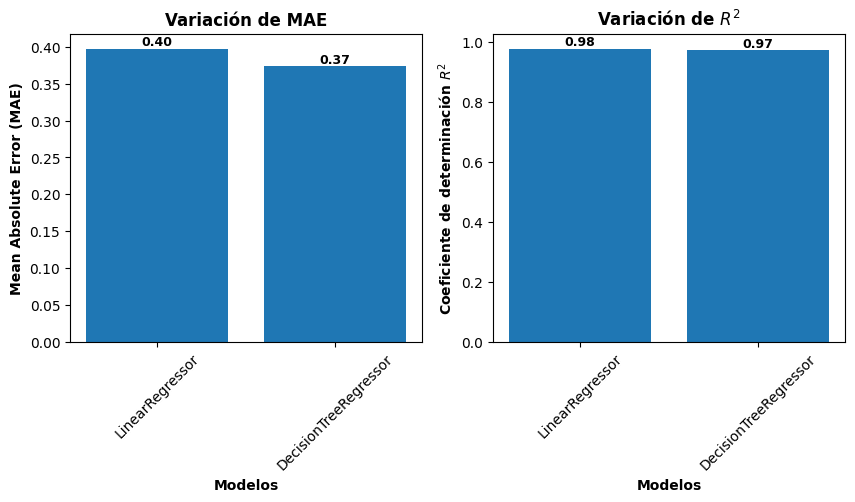

In [ ]:
modelos = ['LinearRegressor', 'DecisionTreeRegressor']
fig, axs = plt.subplots(1, 2,figsize=(10,4))

#axs[0].plot(modelos, history_mae, 'b*--', linewidth=2)
barras_mae = axs[0].bar(modelos, history_mae)
axs[0].set_xlabel("Modelos", fontsize=10, fontweight="bold")
axs[0].tick_params(axis='x', rotation=45)
axs[0].set_ylabel("Mean Absolute Error (MAE)", fontsize=10, fontweight="bold")
axs[0].set_title("Variación de MAE", fontsize=12, fontweight="bold")
for barra in barras_mae:
    altura = barra.get_height()
    axs[0].text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{altura:.2f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

barras_r2 = axs[1].bar(modelos, history_r2)
axs[1].set_xlabel("Modelos", fontsize=10, fontweight="bold")
axs[1].tick_params(axis='x', rotation=45)
axs[1].set_ylabel(f"Coeficiente de determinación $R^2$", fontsize=10, fontweight="bold")
axs[1].set_title(f"Variación de $R^2$", fontsize=12, fontweight="bold");
for barra in barras_r2:
    altura = barra.get_height()
    axs[1].text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{altura:.2f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

El grafico representa la comparacion de ambos modelos, primero vemos la variacion del MAE dando como resultado que el modelo LinearRegressor tiene un MAE de 0.40 y DecisionTreeRegressor un MAE de 0.37.

Por el otro lado podemos observar la variación del R2 de cada modelo, dando como resultado que el modelo LinearRegressor tiene un r2 de 0.98 y el modelo DecisionTreeRegressor tienen un r2 del 0.97.



# Conjunto de datos

In [ ]:
X_train_temp = modelo_dtr.named_steps['duplicados'].transform(X_train)
X_train_temp = modelo_dtr.named_steps['temporal'].transform(X_train_temp)
X_train_temp = modelo_dtr.named_steps['cyclical'].transform(X_train_temp)
X_train_temp = modelo_dtr.named_steps['rolling'].transform(X_train_temp)
X_train_transformed = modelo_dtr.named_steps['preprocesamiento'].transform(X_train_temp)
column_names = modelo_dtr.named_steps['preprocesamiento'].get_feature_names_out()
data_post_pipeline = pd.DataFrame(X_train_transformed, columns=column_names)
data_post_pipeline.head()

,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,sunshine_duration,latitud,longitud,...,hour_cos,month_sin,month_cos,temp_rolling_12h,lluvia_rolling_24h,"Localidad_Punta Arenas, Chile","Localidad_Temuco, Chile","Localidad_Valdivia, Chile",is_day_1.0,is_rainy_hour_1
0,-0.069294,0.600125,-0.368775,0.665952,0.319010,0.523849,-0.375954,1.445727,0.821197,-0.653259,...,0.366748,-1.183398,-0.634599,0.044170,-0.789990,0.0,0.0,0.0,1.0,0.0
1,0.251147,-0.090364,-0.368775,-0.982800,-0.687500,0.110593,-0.375954,-0.737458,0.821197,-0.653259,...,1.231284,-1.367600,0.103699,0.000998,1.991367,0.0,0.0,0.0,0.0,0.0
2,-1.471700,1.653611,-0.368775,-1.484594,-0.213809,0.273935,-0.375954,1.445727,0.821197,-0.653259,...,-1.234797,0.007299,1.382468,0.801394,-0.789990,0.0,0.0,0.0,1.0,0.0
3,0.520660,0.006253,-0.368775,-1.293435,-0.539013,-0.233568,-0.375954,-0.737458,0.821197,-0.653259,...,-0.370261,-1.183398,0.841997,0.454323,-0.789990,0.0,0.0,0.0,0.0,0.0
4,0.200690,1.350209,-0.368775,-1.484594,0.051796,-0.009300,-0.375954,-0.737458,0.821197,-0.653259,...,1.005017,0.694748,1.382468,1.712204,-0.789990,0.0,0.0,0.0,0.0,0.0


**Interpretación de código:**
- En esta celda preparamos y adaptamos los datos de entrenamiento para el modelo del árbol de decisiones. Se transforman las variables originales como humedad o viento y las ajusta a una escala común, esto se hace con el fin de evitar que el modelo le de más importacia a una variable solo porque sus numeros son más grandes.

In [ ]:
data_post_pipeline.to_csv('data_modelo_G1.csv', index=False)
print("Dataset procesado guardado exitosamente como 'data_modelo_G1.csv'")

Dataset procesado guardado exitosamente como 'data_modelo_G1.csv'


# Prueba con datos Nuevos

In [ ]:
def predecir_temperatura(localidad: str, mes: int, hora: int) -> dict:
    # --- Validaciones ---
    localidades_validas = data['Localidad'].unique()
    if localidad not in localidades_validas:
        raise ValueError(f"Localidad '{localidad}' no encontrada.")

    # --- Obtención de parámetros históricos (Funcionalidad) ---
    # Filtramos por localidad y mes para obtener promedios realistas
    filtro = (data['Localidad'] == localidad) & (data['month'] == mes)
    data_filtrada = data[filtro]

    if data_filtrada.empty:
        raise ValueError(f"No hay datos para {localidad} en el mes {mes}")

    prom = data_filtrada.mean(numeric_only=True)

    is_day_val = 1 if 6 <= hora <= 20 else 0
    is_rainy_val = int(round(prom['is_rainy_hour']))

    # --- Construcción del registro para el Pipeline ---
    # Importante: Incluimos 'date' porque los Transformers del Pipeline lo requieren
    nuevo = pd.DataFrame([{
        'date': f"2025-{mes:02d}-01 {hora:02d}:00:00",
        'relative_humidity_2m' : prom['relative_humidity_2m'],
        'apparent_temperature' : prom['apparent_temperature'],
        'precipitation'        : prom['precipitation'],
        'cloud_cover'          : prom['cloud_cover'],
        'wind_speed_10m'       : prom['wind_speed_10m'],
        'wind_direction_10m'   : prom['wind_direction_10m'],
        'rain'                 : prom['rain'],
        'sunshine_duration'    : prom['sunshine_duration'],
        'latitud'              : prom['latitud'],
        'longitud'             : prom['longitud'],
        'Localidad'            : localidad,
        'is_day'               : is_day_val,
        'is_rainy_hour'        : is_rainy_val,
        'temperature_2m'       : prom['temperature_2m'] # Valor base para evitar errores en transform
    }])

    # --- Predicción ---
    pred_lr  = modelo_lr.predict(nuevo)[0]
    pred_dtr = modelo_dtr.predict(nuevo)[0]

    print('=' * 52)
    print(f"  PREDICCIÓN FUNCIONAL PARA: {localidad}")
    print(f"  Mes: {mes} | Hora: {hora:02d}:00")
    print('-' * 52)
    print(f"  Linear Regression: {pred_lr:.2f} °C")
    print(f"  Decision Tree:     {pred_dtr:.2f} °C")
    print('=' * 52)

    return {'LinearRegression': pred_lr, 'DecisionTreeRegressor': pred_dtr}

In [ ]:
# 1. Preparar datos base
data['date'] = pd.to_datetime(data['date'])
data['month'] = data['date'].dt.month

# 2. Generar la columna faltante usando la lógica de RollingFeatures
# Ordenamos para asegurar el cálculo correcto de la media móvil
data = data.sort_values(['Localidad', 'date'])
data['temp_rolling_12h'] = (
    data.groupby('Localidad')['temperature_2m']
    .transform(lambda x: x.rolling(12, min_periods=1).mean())
)

# 3. Realizar el proceso de pivot
data_temp = data.groupby(["Localidad", "month"])["temp_rolling_12h"].mean().reset_index()
data_temp = data_temp.pivot(index="Localidad", columns="month", values="temp_rolling_12h")

data_temp

month,1,2,3,4,5,6,7,8,9,10,11,12
Localidad,,,,,,,,,,,,
"Concepción, Chile",17.218729,17.400471,15.880578,12.923588,10.913967,8.668715,9.440995,10.802016,11.097807,12.657919,14.855758,16.653035
"Punta Arenas, Chile",11.325014,9.576261,8.977967,7.184928,3.883808,3.533875,2.940920,3.723744,5.469969,6.687756,8.329448,10.076249
"Temuco, Chile",16.610789,16.373531,14.732874,11.468032,8.956088,6.451904,7.227201,9.026882,9.846354,10.637287,13.569942,16.348645
"Valdivia, Chile",17.113035,16.139571,14.205203,11.438582,9.214925,6.655330,6.966605,8.859929,9.607870,10.897205,14.150104,17.259414


**Interpretación de código:**
- En esta celda se construye una matriz que resume los promedios históricos de temperatura "temp_rolling_12h", cruzando localidades con los meses del año, esto funciona como una tabla de búsqueda

In [ ]:
print("Localidades disponibles:")
for loc in sorted(data['Localidad'].unique()):
    print(f"  - {loc}")

Localidades disponibles:
  - Concepción, Chile
  - Punta Arenas, Chile
  - Temuco, Chile
  - Valdivia, Chile


In [ ]:
# ── Parámetros de entrada ─────────────────────────
localidad = "Concepción, Chile"   # Nombre exacto de la localidad
mes       = 6                      # 1 = Enero, ..., 12 = Diciembre
hora      = 15                     # Hora del día (0-23)
# ──────────────────────────────────────────────────

resultados = predecir_temperatura(localidad, mes, hora)

  PREDICCIÓN FUNCIONAL PARA: Concepción, Chile
  Mes: 6 | Hora: 15:00
----------------------------------------------------
  Linear Regression: 8.39 °C
  Decision Tree:     8.80 °C


La predicción realizada para Concepción corresponde a una temperatura estimada para el mes de junio a las 15:00 horas.

Los resultados obtenidos fueron:

Linear Regression: 8.39 °C
Decision Tree: 8.80 °C

Ambos modelos generan predicciones muy similares, lo que indica consistencia en los resultados y un comportamiento estable del sistema predictivo. La diferencia entre ambas estimaciones es baja, reflejando que ambos modelos logran capturar adecuadamente los patrones climáticos presentes en los datos históricos.

In [ ]:
# Creamos la tabla resumen con las métricas de tus celdas y la conclusión de overfitting
tabla_resumen_final = pd.DataFrame({
    'R² (Predicción)': [0.98, 0.97],
    'MAE (Predicción)': ['0.40 °C', '0.37 °C'],
    '¿Presenta Overfitting?': [
        'No. Rendimiento altamente estable entre entrenamiento y predicción.',
        'Sí. Error cero en entrenamiento, pero sube ligeramente al predecir.'
    ]
}, index=['Linear Regression', 'Decision Tree Regressor'])

# La mostramos en pantalla
tabla_resumen_final

,R² (Predicción),MAE (Predicción),¿Presenta Overfitting?
Linear Regression,0.98,0.40 °C,No. Rendimiento altamente estable entre entren...
Decision Tree Regressor,0.97,0.37 °C,"Sí. Error cero en entrenamiento, pero sube lig..."


**Interpretación de código:**
- Ambos modelos muestran un r2 muy bueno lo que significa que ambos algoritmos logran interpretar y explicar el 98% de la variabilidad climática real de los datos de prueba.
- Al analizar los errores absolutos medios MAE, el modelo decision tree regressor resulta ser el modelo con mayor precisión, ya que su predicción falla en promedio por solo 0.37 grados celsius, superando el margen de error de la Regresión Lineal 40 grados. Cabe destacar que el Árbol de Decisión presenta un leve sobreentrenamiento overfitting

# Porque usar el modelo
- El modelo de regresión lineal sería el modelo recomendado para la planificación estratégica de LengaMar. Al no presentar overfitting, el modelo generaliza correctamente ante datos de nuevas localidades, lo que lo hace ideal para evaluar la expansión hacia ciudades como Valdivia, Puerto Montt o Temuco. Su estabilidad permite estimar con confianza las condiciones de temperatura esperadas en zonas donde la empresa aún no opera, apoyando decisiones inversión y planificación de rutas turísticas a largo plazo.

- El árbol de decisiones sería el modelo preferido para la operación diaria de las lanchas. Al presentar un MAE de 0.37 grados celsius, ofrece predicciones más precisas que la Regresión Lineal, lo que resulta crítico al momento de decidir si las condiciones climáticas son aptas para realizar un recorrido turístico o si se debe cancelar el servicio por riesgo a los pasajeros. En este contexto, cada décima de grado puede marcar la diferencia entre una operación segura y una suspensión de servicio.